<a href="https://colab.research.google.com/github/prasstyoadhi2/Clustering-ML-of-Person-of-interest-in-Epstein-Files/blob/main/Person_in_Epstein_files_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

print("Silakan klik 'Choose Files' untuk mengupload dataset Epstein Anda:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"\nSip! Data '{file_name}' berhasil dimuat!")

Silakan klik 'Choose Files' untuk mengupload dataset Epstein Anda:


Saving epstein-persons-2026-02-13_cleaned.csv to epstein-persons-2026-02-13_cleaned (1).csv

Sip! Data 'epstein-persons-2026-02-13_cleaned (1).csv' berhasil dimuat!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Import 3 Algoritma Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [ ]:
# ==========================================
# 1. PERSIAPAN DATA (PREPROCESSING)
# ==========================================
# (Asumsi data sudah ada di variabel df dari proses upload sebelumnya)
file_name = 'epstein-persons-2026-02-13_cleaned.csv'
df = pd.read_csv(file_name)

features = ['Flights', 'Documents', 'Connections']
X = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_clusters = 4 # Kita tetap pakai 4 Tier/Ring

In [ ]:
# ==========================================
# 2. MELATIH 3 ALGORITMA CLUSTERING SEKALIGUS
# ==========================================
# Algoritma 1: K-Means
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Algoritma 2: Agglomerative (Hierarchical)
agglo = AgglomerativeClustering(n_clusters=k_clusters)
df['Cluster_Agglo'] = agglo.fit_predict(X_scaled)

# Algoritma 3: Gaussian Mixture Model (GMM) DENGAN PENINGKATAN PERFORMA
# Kunci peningkatannya ada di parameter covariance_type='tied'
gmm = GaussianMixture(n_components=k_clusters, covariance_type='tied', random_state=42)
df['Cluster_GMM'] = gmm.fit_predict(X_scaled)

In [ ]:
# ==========================================
# 3. EVALUASI METRIK (SILHOUETTE SCORE)
# ==========================================
score_kmeans = silhouette_score(X_scaled, df['Cluster_KMeans'])
score_agglo = silhouette_score(X_scaled, df['Cluster_Agglo'])
score_gmm = silhouette_score(X_scaled, df['Cluster_GMM'])

print("="*65)
print("HASIL PERBANDINGAN 3 ALGORITMA CLUSTERING (SILHOUETTE SCORE)")
print("="*65)
print(f"1. K-Means Clustering           : {score_kmeans:.3f}")
print(f"2. Agglomerative Clustering     : {score_agglo:.3f}")
print(f"3. Gaussian Mixture Model (GMM) : {score_gmm:.3f}")
print("="*65)

HASIL PERBANDINGAN 3 ALGORITMA CLUSTERING (SILHOUETTE SCORE)
1. K-Means Clustering           : 0.976
2. Agglomerative Clustering     : 0.926
3. Gaussian Mixture Model (GMM) : 0.979


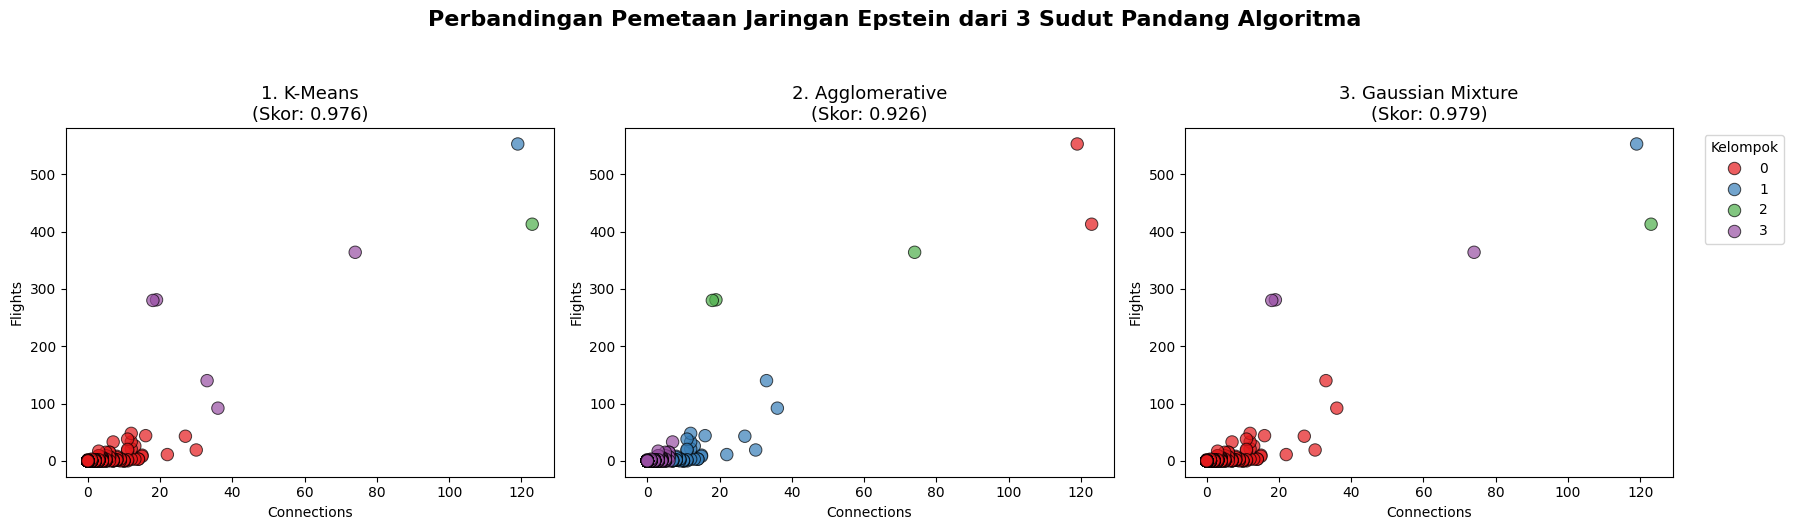

In [ ]:
# ==========================================
# 4. VISUALISASI GRAFIK 3 ALGORITMA
# ==========================================
plt.style.use('default')
# Membuat 3 kanvas grafik berjejer ke samping
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: K-Means
sns.scatterplot(data=df, x='Connections', y='Flights', hue='Cluster_KMeans', palette='Set1', s=80, alpha=0.7, edgecolor='k', ax=axes[0])
axes[0].set_title(f'1. K-Means\n(Skor: {score_kmeans:.3f})', fontsize=13)
axes[0].set_xlabel('Connections')
axes[0].set_ylabel('Flights')
axes[0].legend_.remove() # Sembunyikan legenda agar tidak penuh

# Plot 2: Agglomerative
sns.scatterplot(data=df, x='Connections', y='Flights', hue='Cluster_Agglo', palette='Set1', s=80, alpha=0.7, edgecolor='k', ax=axes[1])
axes[1].set_title(f'2. Agglomerative\n(Skor: {score_agglo:.3f})', fontsize=13)
axes[1].set_xlabel('Connections')
axes[1].set_ylabel('Flights')
axes[1].legend_.remove()

# Plot 3: Gaussian Mixture Model
sns.scatterplot(data=df, x='Connections', y='Flights', hue='Cluster_GMM', palette='Set1', s=80, alpha=0.7, edgecolor='k', ax=axes[2])
axes[2].set_title(f'3. Gaussian Mixture\n(Skor: {score_gmm:.3f})', fontsize=13)
axes[2].set_xlabel('Connections')
axes[2].set_ylabel('Flights')
axes[2].legend(title='Kelompok', bbox_to_anchor=(1.05, 1), loc='upper left') # Munculkan legenda di kanan luar

plt.suptitle('Perbandingan Pemetaan Jaringan Epstein dari 3 Sudut Pandang Algoritma', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. PENJELASAN & DAFTAR NAMA TIAP CLUSTER (DARI GMM)
# ==========================================
print("\n" + "="*80)
print("MEMBEDAH ISI KELOMPOK (Berdasarkan Hasil Algoritma GMM)")
print("="*80)

# Kita urutkan Cluster berdasarkan seberapa sering mereka terbang rata-rata
# agar Cluster 0 selalu yang paling rendah, dan Cluster teratas selalu Ring 1.
cluster_stats = df.groupby('Cluster_GMM')[features].mean().sort_values(by='Flights')
urutan_cluster_logis = cluster_stats.index.tolist()

penjelasan_tier = [
    "KETERLIBATAN RENDAH (Tamu Sesekali / Nama di Dokumen)\nMereka hampir tidak pernah terbang, tapi nama mereka terhubung secara periferal.",
    "KETERLIBATAN MENENGAH (Lingkaran Bisnis / Sosial)\nTerbang beberapa kali, memiliki koneksi menengah dengan jaringan.",
    "KETERLIBATAN TINGGI (Kaki Tangan / Penumpang Rutin)\nTerbang puluhan hingga ratusan kali. Sangat aktif di dalam operasi/jaringan.",
    "INNER CIRCLE (Lingkaran Utama / Bos)\nPusat dari segalanya. Angka penerbangan dan koneksi yang sangat tidak wajar (Ratusan kali)."
]

for urutan, cluster_id in enumerate(urutan_cluster_logis):
    # Ambil semua anggota di cluster ini
    anggota = df[df['Cluster_GMM'] == cluster_id]

    # Rata-rata interaksi di cluster ini
    avg_flights = anggota['Flights'].mean()
    avg_conns = anggota['Connections'].mean()
    avg_docs = anggota['Documents'].mean()

    print(f"\n💎 KELOMPOK TINGKAT {urutan + 1} (ID Mesin: Cluster {cluster_id}) - Total: {len(anggota)} Orang")
    print(f"Penjelasan : {penjelasan_tier[urutan]}")
    print(f"Rata-rata  : {avg_flights:.1f} Penerbangan | {avg_conns:.1f} Koneksi | {avg_docs:.1f} Dokumen")
    print("-" * 60)

    # Tampilkan 15 orang teratas di kelompok ini sebagai representasi
    top_15 = anggota.sort_values(by=['Flights', 'Connections'], ascending=[False, False]).head(15)

    # Format tabel rapi
    print(f"{'NAMA':<25} | {'KATEGORI':<12} | {'FLIGHTS':<7} | {'CONNECTIONS'}")
    print("-" * 60)
    for _, row in top_15.iterrows():
        print(f"{row['Name'][:23]:<25} | {row['Category'][:10]:<12} | {row['Flights']:<7} | {row['Connections']}")


MEMBEDAH ISI KELOMPOK (Berdasarkan Hasil Algoritma GMM)

💎 KELOMPOK TINGKAT 1 (ID Mesin: Cluster 0) - Total: 1259 Orang
Penjelasan : KETERLIBATAN RENDAH (Tamu Sesekali / Nama di Dokumen)
Mereka hampir tidak pernah terbang, tapi nama mereka terhubung secara periferal.
Rata-rata  : 0.7 Penerbangan | 0.7 Koneksi | 0.6 Dokumen
------------------------------------------------------------
NAMA                      | KATEGORI     | FLIGHTS | CONNECTIONS
------------------------------------------------------------
Nadia Marcinkova          | associate    | 140     | 33
Lesley Groff              | associate    | 92      | 36
Virginia Giuffre          | other        | 48      | 12
Bill Hammond              | associate    | 44      | 16
Adriana Ross              | associate    | 43      | 27
Bill Clinton              | politician   | 38      | 11
Alan Dershowitz           | legal        | 33      | 12
Doug Band                 | politician   | 33      | 7
Prince Andrew             | royalty     